## Segmentación del hundimiento

In [ ]:
import numpy as np
import pywt
from scipy.signal import hilbert
from scipy.ndimage import binary_closing, binary_opening
from typing import List, Tuple

# =============================================================================
# SECCIÓN 1: UTILIDADES BÁSICAS
# =============================================================================

def muestras_por_ciclo(fs: int, f_nom: float = 60.0) -> int:
    """Número de muestras por ciclo de la señal de red."""
    return int(round(fs / f_nom))

def convertir_mascara_a_intervalos(mascara: np.ndarray) -> List[Tuple[int, int]]:
    """Convierte una máscara booleana en intervalos (ini, fin)."""
    if mascara.size == 0 or not mascara.any():
        return []
    m = mascara.astype(np.int8)
    dm = np.diff(np.r_[0, m, 0])
    inicios = np.flatnonzero(dm == 1)
    finales = np.flatnonzero(dm == -1)
    return list(zip(inicios, finales))

def unir_intervalos(intervalos: List[Tuple[int, int]], margen_muestras: int) -> List[Tuple[int, int]]:
    """Une intervalos cercanos o solapados (separados por menos de margen_muestras)."""
    if not intervalos:
        return []
    intervalos.sort(key=lambda x: x[0])
    union = [intervalos[0]]
    for ini, fin in intervalos[1:]:
        u_ini, u_fin = union[-1]
        if ini <= (u_fin + margen_muestras):
            union[-1] = (u_ini, max(u_fin, fin))
        else:
            union.append((ini, fin))
    return union

def postprocesar_mascara(mascara: np.ndarray, mpc: int) -> np.ndarray:
    """Suaviza la máscara eliminando picos y rellenando huecos pequeños."""
    se_cierre = np.ones(max(1, mpc // 4), dtype=bool)  # cierra huecos cortos
    se_apertura = np.ones(max(1, mpc // 8), dtype=bool)  # elimina picos breves
    m = binary_closing(mascara, structure=se_cierre)
    m = binary_opening(m, structure=se_apertura)
    return m

# =============================================================================
# SECCIÓN 2: GENERACIÓN DE MÁSCARAS (TRIGGERS)
# =============================================================================

def generar_mascara_rms(senal: np.ndarray, fs: int, f_nom: float = 60.0,
                        umbral_sag: float = 0.90, percentil_ref: float = 95.0) -> np.ndarray:
    """Máscara basada en RMS por medio ciclo con solapamiento 50%."""
    mpc = muestras_por_ciclo(fs, f_nom)
    hop = mpc // 2
    if hop <= 0:
        return np.zeros(len(senal), dtype=bool)

    rms_vals, centros = [], []
    for ini in range(0, len(senal) - hop + 1, hop):
        fin = min(ini + mpc, len(senal))
        if fin - ini < hop: break
        rms_vals.append(np.sqrt(np.mean(senal[ini:fin]**2)))
        centros.append((ini + fin) // 2)

    if not rms_vals:
        return np.zeros(len(senal), dtype=bool)

    v_nominal = np.percentile(rms_vals, percentil_ref)
    umbral = umbral_sag * v_nominal

    mascara = np.zeros(len(senal), dtype=bool)
    for centro, rms_val in zip(centros, rms_vals):
        if rms_val < umbral:
            ini_p = max(0, centro - hop)
            fin_p = min(len(senal), centro + hop)
            mascara[ini_p:fin_p] = True
    
    return postprocesar_mascara(mascara, mpc)
    

def generar_mascara_swt(senal: np.ndarray, wavelet: str = 'db4', niveles: int = 4) -> np.ndarray:
    """Máscara basada en energía de la SWT (Wavelet Estacionaria)."""
    coefs = pywt.swt(senal, wavelet, level=niveles)
    energia = np.sum([cD**2 for (_, cD) in coefs], axis=0)

    mad = np.median(np.abs(energia - np.median(energia)))
    sigma = mad / 0.6745 if mad > 0 else 1e-9
    umbral = sigma * np.sqrt(2 * np.log(len(senal)))

    return postprocesar_mascara(energia > umbral, muestras_por_ciclo(7200))

def generar_mascara_hilbert(senal: np.ndarray, percentil_ref: float = 95.0,
                            umbral_sag: float = 0.90, umbral_swell: float = 1.10) -> np.ndarray:
    """Máscara basada en la envolvente de Hilbert."""
    envolvente = np.abs(hilbert(senal))
    v_ref = np.percentile(envolvente, percentil_ref)
    if v_ref < 1e-9:
        return np.zeros_like(envolvente, dtype=bool)

    caidas = envolvente < (umbral_sag * v_ref)
    subidas = envolvente > (umbral_swell * v_ref)
    return postprocesar_mascara(caidas | subidas, muestras_por_ciclo(7200))

# =============================================================================
# SECCIÓN 3: DETECTORES DE EVENTOS INDIVIDUALES
# =============================================================================

def detectar_eventos_rms(senal: np.ndarray, fs: int, umbral_sag: float = 0.9,
                         ciclos_minimos: float = 0.5) -> List[Tuple[int, int]]:
    """Detecta eventos usando solo RMS."""
    mpc = muestras_por_ciclo(fs)
    mascara = generar_mascara_rms(senal, fs, umbral_sag=umbral_sag)
    intervalos = convertir_mascara_a_intervalos(mascara)
    min_duracion = int(ciclos_minimos * mpc)
    return [(i, f) for i, f in intervalos if (f - i) >= min_duracion]

def detectar_eventos_hilbert(senal: np.ndarray, fs: int, umbral_sag: float = 0.9,
                             umbral_swell: float = 1.1, ciclos_minimos: float = 0.5) -> List[Tuple[int, int]]:
    """Detecta eventos usando solo Hilbert."""
    mpc = muestras_por_ciclo(fs)
    mascara = generar_mascara_hilbert(senal, umbral_sag=umbral_sag, umbral_swell=umbral_swell)
    intervalos = convertir_mascara_a_intervalos(mascara)
    min_duracion = int(ciclos_minimos * mpc)
    return [(i, f) for i, f in intervalos if (f - i) >= min_duracion]

def detectar_eventos_swt(senal: np.ndarray, fs: int, ciclos_minimos: float = 0.1) -> List[Tuple[int, int]]:
    """Detecta eventos usando solo SWT."""
    mpc = muestras_por_ciclo(fs)
    mascara = generar_mascara_swt(senal)
    intervalos = convertir_mascara_a_intervalos(mascara)
    min_duracion = int(ciclos_minimos * mpc)
    return [(i, f) for i, f in intervalos if (f - i) >= min_duracion]

# =============================================================================
# SECCIÓN 4: DETECTOR AVANZADO CON FUSIÓN
# =============================================================================
def refinar_bordes_con_swt(
    eventos_prelim: List[Tuple[int, int]],
    intervalos_swt: List[Tuple[int, int]],
    fs: int,
    n_total: int,
    f_nom: float = 60.0,
    ventana_busqueda_ciclos: float = 0.75
) -> List[Tuple[int, int]]:
    """
    Refina los bordes de eventos preliminares usando la lógica correcta:
    - Inicio: Se alinea con el ÚLTIMO transitorio SWT antes del borde.
    - Fin: Se alinea con el PRIMER transitorio SWT después del borde.
    """
    if not intervalos_swt or not eventos_prelim:
        return eventos_prelim # No hay nada que refinar

    mpc = muestras_por_ciclo(fs, f_nom)
    ventana_muestras = int(ventana_busqueda_ciclos * mpc)

    # Crear un solo arreglo con todos los puntos de cambio de SWT (inicios y fines)
    puntos_swt = sorted(list(set([p for a, b in intervalos_swt for p in (a, b)])))
    puntos_swt = np.array(puntos_swt)

    eventos_refinados = []
    for ini_aprox, fin_aprox in eventos_prelim:
        
        # --- Refinar INICIO ---
        # Ventana de búsqueda: desde mucho antes hasta un poco después del inicio aprox.
        lim_inf_ini = ini_aprox - ventana_muestras
        lim_sup_ini = ini_aprox + int(0.1 * mpc) # Pequeña tolerancia hacia adelante
        
        # Candidatos: puntos SWT que caen ANTES del límite superior de la ventana
        candidatos_ini = puntos_swt[puntos_swt <= lim_sup_ini]
        
        # De esos, nos quedamos con el que esté MÁS CERCA del inicio (el último)
        if candidatos_ini.size > 0:
            nuevo_inicio = max(candidatos_ini) # El ÚLTIMO transitorio antes
        else:
            nuevo_inicio = ini_aprox # Fallback: no se encontró candidato

        # --- Refinar FIN ---
        # Ventana de búsqueda: desde un poco antes del fin hasta mucho después
        lim_inf_fin = fin_aprox - int(0.1 * mpc) # Pequeña tolerancia hacia atrás
        lim_sup_fin = fin_aprox + ventana_muestras
        
        # Candidatos: puntos SWT que caen DESPUÉS del límite inferior de la ventana
        candidatos_fin = puntos_swt[puntos_swt >= lim_inf_fin]
        
        # De esos, nos quedamos con el que esté MÁS CERCA del fin (el primero)
        if candidatos_fin.size > 0:
            nuevo_fin = min(candidatos_fin) # El PRIMER transitorio después
        else:
            nuevo_fin = fin_aprox # Fallback: no se encontró candidato

        eventos_refinados.append((
            max(0, nuevo_inicio),
            min(n_total, nuevo_fin)
        ))

    return eventos_refinados
def detectar_eventos_con_fusion(senal: np.ndarray, fs: int, umbral_sag: float = 0.9,
                                umbral_swell: float = 1.1, ciclos_minimos: float = 0.5) -> List[Tuple[int, int]]:
    """Fusiona RMS, SWT y Hilbert para una detección más robusta."""
    mpc = muestras_por_ciclo(fs)
    medio_ciclo = mpc // 2
    if medio_ciclo <= 0:
        return []

    # Máscaras individuales
    rms_mask = generar_mascara_rms(senal, fs, umbral_sag=umbral_sag)
    swt_mask = generar_mascara_swt(senal)
    hilbert_mask = generar_mascara_hilbert(senal, umbral_sag=umbral_sag, umbral_swell=umbral_swell)

    # Coincidencias SWT & Hilbert
    apoyo = swt_mask & hilbert_mask
    intervalos_apoyo = convertir_mascara_a_intervalos(apoyo)
    apoyo_filtrado = np.zeros_like(apoyo)
    for ini, fin in intervalos_apoyo:
        if (fin - ini) >= max(1, mpc // 4):
            apoyo_filtrado[ini:fin] = True

    # Lógica: RMS obligatorio + apoyo SWT/Hilbert
    activacion = rms_mask & (swt_mask | hilbert_mask | apoyo_filtrado)
    preliminares = convertir_mascara_a_intervalos(activacion)
    intervalos_swt = convertir_mascara_a_intervalos(swt_mask)
    # Refinar bordes
    refinados = refinar_bordes_con_swt(
        preliminares,
        intervalos_swt,
        fs=fs,
        n_total=len(senal),
        ventana_busqueda_ciclos=0.75,
    )

    # Unir y filtrar
    unidos = unir_intervalos(refinados, margen_muestras=medio_ciclo)
    min_duracion = int(ciclos_minimos * mpc)
    return [(i, f) for i, f in unidos if (f - i) >= min_duracion]


## Graficar_Mascaras

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Tuple

def _setup_academic_style():
    """Configura los parámetros de Matplotlib para un estilo tipo IEEE."""
    plt.rcParams['font.family'] = 'serif'
    plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
    plt.rcParams['mathtext.fontset'] = 'stix'
    plt.rcParams['font.size'] = 12
    plt.rcParams['axes.labelsize'] = 12
    plt.rcParams['axes.titlesize'] = 14
    plt.rcParams['xtick.labelsize'] = 10
    plt.rcParams['ytick.labelsize'] = 10
    plt.rcParams['legend.fontsize'] = 11
    plt.rcParams['figure.figsize'] = (10, 4)
    plt.rcParams['lines.linewidth'] = 1.5

def señal_mascara(
    signal: np.ndarray,
    intervals: List[Tuple[int, int]],
    title: str,
    fs: int = None,
    y_label: str = "Amplitud",
    detection_label: str = "Detección"
):
    """
    Genera un gráfico de una señal, sombreando las áreas definidas por una lista de intervalos.

    Args:
        signal (np.ndarray): La señal de entrada a graficar.
        intervals (List[Tuple[int, int]]): Una lista de tuplas, donde cada tupla
                                            es un par (inicio, fin) de un evento.
        title (str): El título del gráfico.
        fs (int, optional): La frecuencia de muestreo para el eje de tiempo en segundos.
        y_label (str, optional): Etiqueta del eje Y.
        detection_label (str, optional): Etiqueta para la leyenda del área sombreada.
    """
    _setup_academic_style()
    fig, ax = plt.subplots()

    # 1. Crear la máscara booleana a partir de la lista de intervalos
    mask = np.zeros_like(signal, dtype=bool)
    for start, end in intervals:
        # Asegurarse de que los índices están dentro de los límites
        start_idx = max(0, start)
        end_idx = min(len(signal), end)
        mask[start_idx:end_idx] = True

    # 2. Crear el eje de tiempo o de muestras
    if fs:
        time_ax = np.arange(len(signal)) / fs
        x_label = "Tiempo (s)"
    else:
        time_ax = np.arange(len(signal))/fs
        x_label = "Tiempo (n)"

    # 3. Graficar la señal y sombrear usando la máscara recién creada
    ax.plot(time_ax, signal, color='#0072B2', label='Señal')
    ax.fill_between(
        time_ax, ax.get_ylim()[0], ax.get_ylim()[1],
        where=mask,
        color='#D55E00', alpha=0.4, label=detection_label, interpolate=True
    )

    # 4. Configuración final del gráfico (títulos, ejes, etc.)
    ax.set_xlabel(x_label, weight='bold')
    ax.set_ylabel(y_label, weight='bold')
    ax.set_title(title, weight='bold', pad=15)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, color='gray')
    ax.tick_params(direction='in', top=True, right=True)
    ax.set_xlim(time_ax[0], time_ax[-1])
    ax.legend(loc='upper right')

    # 5. Guardar y mostrar
    fig.tight_layout()
    file_name = f"{title.replace(' ', '_').lower()}.svg"
    #plt.savefig(file_name, format='svg', dpi=300)
    print(f"Gráfico guardado como: {file_name}")
    plt.show()
    
def plot_diagnostico_algoritmo(
    signal: np.ndarray,
    tipo_detector: str,
    datos_diagnostico: Tuple,
    title: str,
    fs: int
):
    """
    Genera un único gráfico de diagnóstico para el tipo de detector especificado.

    Args:
        signal (np.ndarray): La señal original.
        tipo_detector (str): El tipo de detector a graficar. Acepta 'rms', 'hilbert', 'swt'.
        datos_diagnostico (Tuple): La tupla de datos retornada por la función 'generar_diagnostico_*'.
        title (str): Título del gráfico.
        fs (int): Frecuencia de muestreo.
    """
    _setup_academic_style()
    # Usa un tamaño de figura para un solo gráfico
    fig, ax = plt.subplots(figsize=(10, 4))
    time_ax = np.arange(len(signal)) / fs

    # --- Lógica para seleccionar qué graficar ---
    
    if tipo_detector.lower() == 'rms':
        mascara, (vals, centers), umbral = datos_diagnostico
        time_ax_vista = centers / fs
        
        ax.plot(time_ax_vista, vals, color='#0072B2', marker='.', linestyle='-', ms=4, label='Vista RMS')
        ax.axhline(umbral, color='red', linestyle='--', label=f'Umbral ({umbral:.2f})')
        ax.set_ylabel("Amplitud")

    elif tipo_detector.lower() == 'hilbert':
        mascara, envolvente, (sag_thr, swell_thr) = datos_diagnostico
        
        ax.plot(time_ax, envolvente, color='#D55E00', label='Vista Hilbert')
        ax.axhline(sag_thr, color='red', linestyle='--', label=f'Umbral Sag ({sag_thr:.2f})')
        ax.axhline(swell_thr, color='darkorange', linestyle=':', label=f'Umbral Swell ({swell_thr:.2f})')
        ax.set_ylabel("Amplitud")

    elif tipo_detector.lower() == 'swt':
        mascara, energia, umbral = datos_diagnostico
        ax_twin = ax.twinx() # Necesita doble eje
        ax_twin.plot(time_ax, energia, color='#009E73', label='Vista SWT')
        ax_twin.axhline(umbral, color='red', linestyle='--', label=f'Umbral Donoho ({umbral:.2f})')
        ax.set_ylabel("Amplitud Señal")
        ax_twin.set_ylabel("Energía SWT", color='#009E73')

    else:
        raise ValueError(f"Tipo de detector '{tipo_detector}' no reconocido. Use 'rms', 'hilbert', o 'swt'.")

    # --- Elementos comunes del gráfico ---
    ax.fill_between(time_ax, *ax.get_ylim(), where=mascara, color='gray', alpha=0.3, label='Detección Final')
    ax.set_title(title, weight='bold', pad=15)
    ax.set_xlabel("Tiempo (s)", weight='bold')
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    
    # Unir leyendas si hay doble eje (caso SWT)
    if tipo_detector.lower() == 'swt':
        lines, labels = ax.get_legend_handles_labels()
        lines2, labels2 = ax_twin.get_legend_handles_labels()
        ax.legend(lines + lines2, labels + labels2, loc='upper right')
    else:
        ax.legend(loc='upper right')

    fig.tight_layout()
    plt.show()


In [3]:
def generar_diagnostico_rms(
    senal: np.ndarray, fs: int, f_nom: float = 60.0,
    umbral_sag: float = 0.90, percentil_ref: float = 95.0
):
    """
    Diagnóstico RMS: devuelve (mascara, (rms_vals, centros), umbral_calculado).
    Coincide con el comportamiento de generar_mascara_rms (ventana 1 ciclo, hop 1/2 ciclo).
    """
    mpc = muestras_por_ciclo(fs, f_nom)
    hop = mpc // 2
    if hop <= 0:
        return np.zeros_like(senal, dtype=bool), (np.array([]), np.array([])), 0.0

    rms_vals, centros = [], []
    for ini in range(0, len(senal) - hop + 1, hop):
        fin = min(ini + mpc, len(senal))
        if fin - ini < hop:
            break
        rms_vals.append(np.sqrt(np.mean(senal[ini:fin] ** 2)))
        centros.append((ini + fin) // 2)

    rms_vals = np.array(rms_vals)
    centros = np.array(centros)

    if rms_vals.size == 0:
        return np.zeros_like(senal, dtype=bool), (rms_vals, centros), 0.0

    v_nominal = np.percentile(rms_vals, percentil_ref)
    umbral_calculado = umbral_sag * v_nominal

    mascara = np.zeros(len(senal), dtype=bool)
    for c, r in zip(centros, rms_vals):
        if r < umbral_calculado:
            ini_p = max(0, c - hop)
            fin_p = min(len(senal), c + hop)
            mascara[ini_p:fin_p] = True

    mascara_final = postprocesar_mascara(mascara, mpc)
    return mascara_final, (rms_vals, centros), float(umbral_calculado)


def generar_diagnostico_hilbert(
    senal: np.ndarray, fs: int, f_nom: float = 60.0,
    umbral_sag: float = 0.90, umbral_swell: float = 1.10,
    percentil_ref: float = 95.0
):
    """
    Diagnóstico Hilbert: devuelve (mascara, envolvente, (umbral_sag_calc, umbral_swell_calc)).
    Coincide con generar_mascara_hilbert (mismo cálculo y postproceso).
    """
    envolvente = np.abs(hilbert(senal))
    v_ref = np.percentile(envolvente, percentil_ref)

    if v_ref < 1e-9:
        m = np.zeros_like(envolvente, dtype=bool)
        return m, envolvente, (0.0, 0.0)

    umbral_sag_calc = umbral_sag * v_ref
    umbral_swell_calc = umbral_swell * v_ref

    mascara_raw = (envolvente < umbral_sag_calc) | (envolvente > umbral_swell_calc)

    mpc = muestras_por_ciclo(fs, f_nom)
    mascara_final = postprocesar_mascara(mascara_raw, mpc)

    return mascara_final, envolvente, (float(umbral_sag_calc), float(umbral_swell_calc))


def generar_diagnostico_swt(
    senal: np.ndarray, fs: int, f_nom: float = 60.0,
    wavelet: str = 'db4', niveles: int = 4
):
    """
    Diagnóstico SWT: devuelve (mascara, energia, umbral_donoho).
    Coincide con generar_mascara_swt (energía de detalles + umbral robusto) y mismo postproceso.
    """
    coefs = pywt.swt(senal, wavelet, level=niveles)
    energia = np.sum([cD**2 for (_, cD) in coefs], axis=0)

    mad = np.median(np.abs(energia - np.median(energia)))
    sigma = (mad / 0.6745) if mad > 0 else 1e-9
    umbral_donoho = sigma * np.sqrt(2 * np.log(len(senal)))

    mpc = muestras_por_ciclo(fs, f_nom)
    mascara_final = postprocesar_mascara(energia > umbral_donoho, mpc)

    return mascara_final, energia, float(umbral_donoho)

## Pruebas 

Valor nominal RMS (percentil 95.0): 0.7119
Valor nominal RMS (percentil 95.0): 0.7119
[(np.int64(1440), np.int64(4440))]
[(np.int64(1471), np.int64(4386))]
[(np.int64(499), np.int64(571)), (np.int64(693), np.int64(733)), (np.int64(776), np.int64(818)), (np.int64(1246), np.int64(1280)), (np.int64(1459), np.int64(1530)), (np.int64(1573), np.int64(1595)), (np.int64(2841), np.int64(2923)), (np.int64(3145), np.int64(3168)), (np.int64(3319), np.int64(3336)), (np.int64(3392), np.int64(3416)), (np.int64(3870), np.int64(3898)), (np.int64(4352), np.int64(4401)), (np.int64(4453), np.int64(4494)), (np.int64(4695), np.int64(4733)), (np.int64(4811), np.int64(4830)), (np.int64(4992), np.int64(5065)), (np.int64(5163), np.int64(5186)), (np.int64(5708), np.int64(5723)), (np.int64(5953), np.int64(6059)), (np.int64(6195), np.int64(6221)), (np.int64(6499), np.int64(6562))]
[(np.int64(1459), np.int64(4401))]
Gráfico guardado como: señal_con_máscara_rms.svg


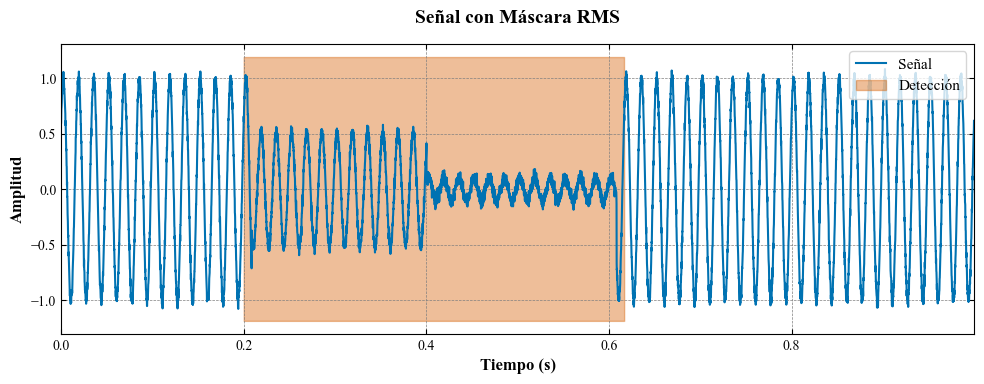

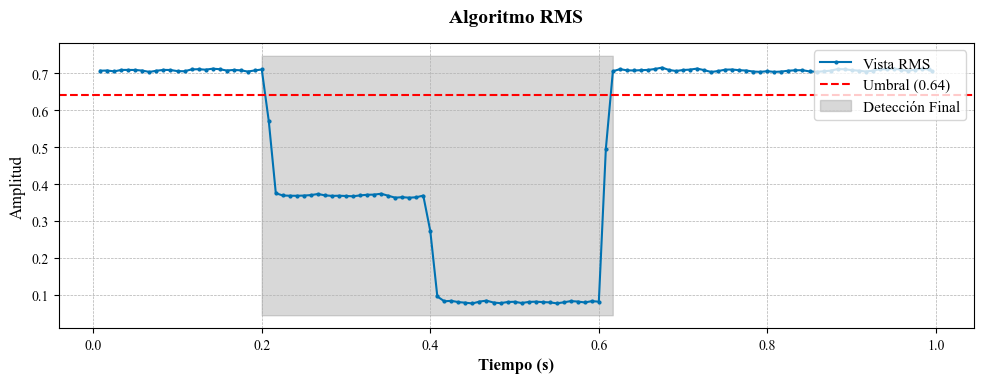

Gráfico guardado como: señal_con_máscara_hilbert.svg


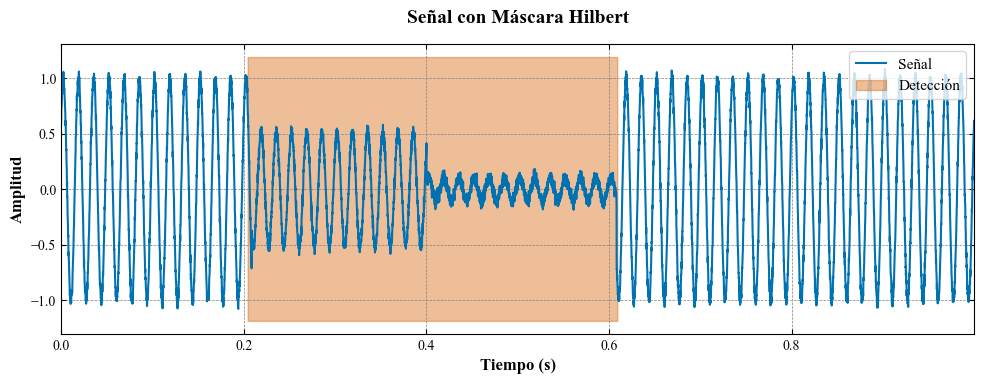

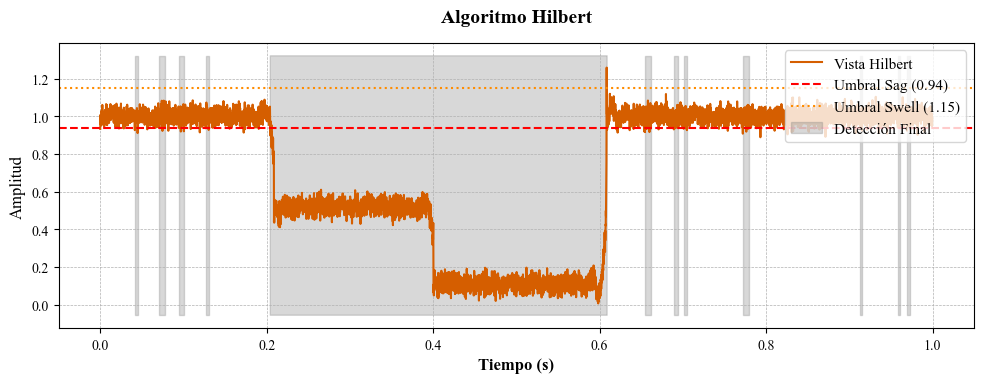

Gráfico guardado como: señal_con_máscara_wavelet.svg


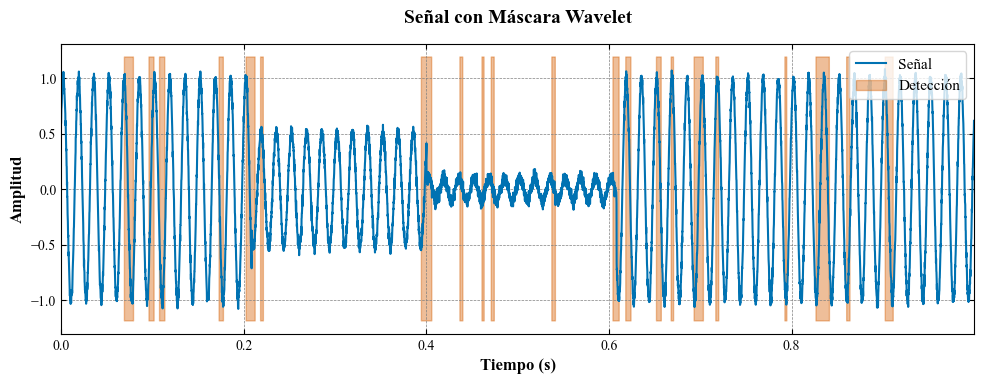

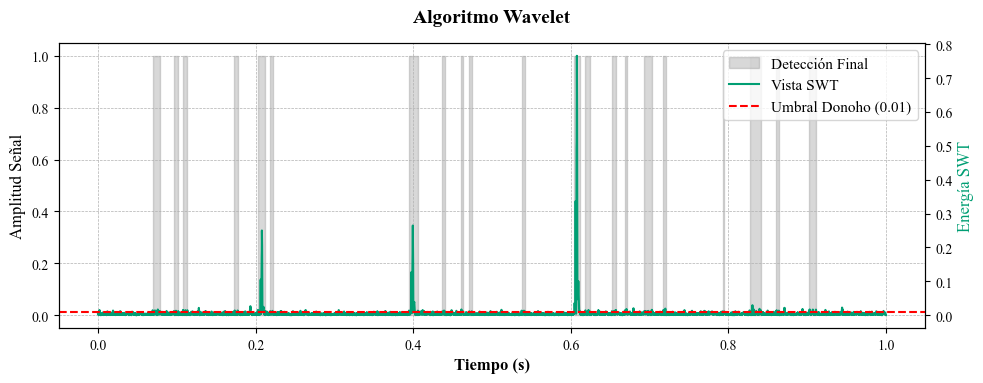

Gráfico guardado como: señal_con_máscara_fusión.svg


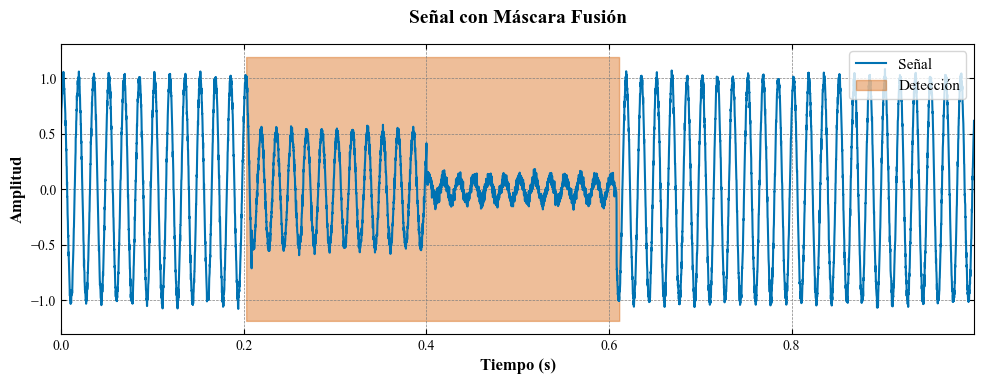

In [4]:
import pandas as pd

data0 = r'C:\Users\juand\Documentos\Juan David Saa\Proyecto_Grado\Pruebas_2\Normal\Clase_0_normal.csv'
data1 = r'C:\Users\juand\Documentos\Juan David Saa\Proyecto_Grado\Pruebas_2\Sag\Clase_1_sag.csv'
data2 = r'C:\Users\juand\Documentos\Juan David Saa\Proyecto_Grado\Pruebas_2\Sag_Armonic\Clase_2_Armonico.csv'
data3 = r'C:\Users\juand\Documentos\Juan David Saa\Proyecto_Grado\Pruebas_2\Sag_Multiple\Clase_3_sagmultiple.csv'
data4 = r'C:\Users\juand\Documentos\Juan David Saa\Proyecto_Grado\Pruebas_2\Sag_Notch\Clase_4_sagnotch.csv'
data5 = r'C:\Users\juand\Documentos\Juan David Saa\Proyecto_Grado\Pruebas_2\Sag_Transitorios\Clase_5_Transitorios.csv'

data2 =pd.read_csv(data3)

senal = data2['Sag_2780'].to_numpy()


datos_rms = generar_diagnostico_rms(senal,7200)
datos_hilbert = generar_diagnostico_hilbert(senal,7200)
datos_wavelet = generar_diagnostico_swt(senal,7200)

mascara_rms = detectar_eventos_rms(senal,7200)
mascara_hilbert = detectar_eventos_hilbert(senal,7200)
mascara_wavelet = detectar_eventos_swt(senal,7200)
mascara_fusion = detectar_eventos_con_fusion(senal,7200)

print(mascara_rms)
print(mascara_hilbert)
print(mascara_wavelet)
print(mascara_fusion)


señal_mascara(senal,mascara_rms,"Señal con Máscara RMS",7200)
plot_diagnostico_algoritmo(senal,"RMS",datos_rms,"Algoritmo RMS",7200)
señal_mascara(senal,mascara_hilbert,"Señal con Máscara Hilbert",7200)
plot_diagnostico_algoritmo(senal,"Hilbert",datos_hilbert,"Algoritmo Hilbert",7200)
señal_mascara(senal,mascara_wavelet,"Señal con Máscara Wavelet",7200)
plot_diagnostico_algoritmo(senal,"swt",datos_wavelet,"Algoritmo Wavelet",7200)
señal_mascara(senal,mascara_fusion,"Señal con Máscara Fusión",7200)